In [112]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Task 1: Data Cleaning and Formatting

In [113]:
df = pd.read_csv("blackrock.csv")

In [114]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   TransactionID      800 non-null    int64  
 1   CustomerID         800 non-null    object 
 2   AccountID          800 non-null    object 
 3   AccountType        800 non-null    object 
 4   TransactionType    800 non-null    object 
 5   Product            800 non-null    object 
 6   Firm               800 non-null    object 
 7   Region             800 non-null    object 
 8   Manager            800 non-null    object 
 9   TransactionDate    800 non-null    object 
 10  TransactionAmount  800 non-null    float64
 11  AccountBalance     800 non-null    float64
 12  RiskScore          800 non-null    float64
 13  CreditRating       800 non-null    int64  
 14  TenureMonths       800 non-null    int64  
dtypes: float64(3), int64(3), object(9)
memory usage: 93.9+ KB


,TransactionID,TransactionAmount,AccountBalance,RiskScore,CreditRating,TenureMonths
count,800.00,800.00,800.00,800.00,800.00,800.00
mean,100.70,54501.87,72947.11,0.47,580.01,125.25
std,58.59,29676.38,34206.07,0.23,154.08,67.30
min,1.00,-27916.91,-35891.00,-0.29,306.00,6.00
25%,50.75,34600.68,51133.06,0.31,451.75,68.00
50%,98.50,55524.08,73006.75,0.46,575.00,127.00
75%,154.00,73485.55,94553.23,0.63,712.25,183.25
max,199.00,165004.54,171767.66,1.20,849.00,239.00


In [115]:
df.head()

,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,TransactionAmount,AccountBalance,RiskScore,CreditRating,TenureMonths
0,109,CUST1913,ACC64393,Credit,Withdrawal,Home Loan,Firm A,West,Manager 1,17-07-2023,47387.11,2980.57,0.78,784,170
1,19,CUST1569,ACC66190,Current,Payment,Personal Loan,Firm C,South,Manager 4,13-01-2023,55806.54,27996.69,0.30,336,197
2,14,CUST5558,ACC71426,Current,Withdrawal,Mutual Fund,Firm C,North,Manager 2,28-09-2023,51080.48,81482.16,0.39,712,95
3,107,CUST4241,ACC49422,Loan,Deposit,Credit Card,Firm D,Central,Manager 1,05-02-2023,70472.70,39598.37,0.56,414,168
4,7,CUST2578,ACC88252,Loan,Deposit,Savings Account,Firm B,East,Manager 4,19-11-2023,29830.49,111731.99,0.66,391,20


In [116]:
df.dtypes

TransactionID          int64
CustomerID            object
AccountID             object
AccountType           object
TransactionType       object
Product               object
Firm                  object
Region                object
Manager               object
TransactionDate       object
TransactionAmount    float64
AccountBalance       float64
RiskScore            float64
CreditRating           int64
TenureMonths           int64
dtype: object

In [117]:
df.isnull().sum()

TransactionID        0
CustomerID           0
AccountID            0
AccountType          0
TransactionType      0
Product              0
Firm                 0
Region               0
Manager              0
TransactionDate      0
TransactionAmount    0
AccountBalance       0
RiskScore            0
CreditRating         0
TenureMonths         0
dtype: int64

# 1- Remove/treat any special characters or non-numeric entries from financial fields.
# 2- Convert currency amounts into numerical format.

The financial columns (TransactionAmount, AccountBalance) were examined using df.info() and df.dtypes. It was observed that these columns were already in numeric format (float64), indicating the absence of special characters such as currency symbols or commas.

Additionally, validation checks confirmed that there were no non-numeric entries present in these fields. Therefore, no further cleaning or conversion was required for these columns.

# 3- Validate and format date columns.

In [121]:
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'], errors='coerce')

In [122]:
df.dtypes

TransactionID                 int64
CustomerID                   object
AccountID                    object
AccountType                  object
TransactionType              object
Product                      object
Firm                         object
Region                       object
Manager                      object
TransactionDate      datetime64[ns]
TransactionAmount           float64
AccountBalance              float64
RiskScore                   float64
CreditRating                  int64
TenureMonths                  int64
dtype: object

In [123]:
df.isnull().sum()

TransactionID        0
CustomerID           0
AccountID            0
AccountType          0
TransactionType      0
Product              0
Firm                 0
Region               0
Manager              0
TransactionDate      0
TransactionAmount    0
AccountBalance       0
RiskScore            0
CreditRating         0
TenureMonths         0
dtype: int64

# 4- Ensure account types and transaction categories are standardized.

In [124]:
df['TransactionType'].unique()

array(['Withdrawal', 'Payment', 'Deposit', 'Transfer'], dtype=object)

In [125]:
df['AccountType'].unique()

array(['Credit', 'Current', 'Loan', 'Savings'], dtype=object)

In [126]:
# They are clean , properly formatted no duplicates , no abbrevations so no major corection is required
# But still there could be hidden spaces no visible in .unique()

In [127]:
df['TransactionType'] = df['TransactionType'].str.strip()

In [128]:
df['AccountType'] = df['AccountType'].str.strip()

In [129]:
df.to_csv("cleaned_blackrock.csv", index=False)

### Task 2: Descriptive Transactional Analysis 

# 1- Calculate monthly and yearly summaries of total credits, debits, and net transaction volume.

In [130]:
# Extract Year & Month
df['Year'] = df['TransactionDate'].dt.year
df['Month'] = df['TransactionDate'].dt.month

In [131]:
# Separate Credit and Debit
credit_df = df[df['TransactionType'] == 'Deposit']
debit_df = df[df['TransactionType'].isin(['Withdrawal', 'Payment', 'Transfer'])]

In [132]:
credit_df

,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,TransactionAmount,AccountBalance,RiskScore,CreditRating,TenureMonths,Year,Month
3,107,CUST4241,ACC49422,Loan,Deposit,Credit Card,Firm D,Central,Manager 1,2023-02-05,70472.70,39598.37,0.56,414,168,2023,2
4,7,CUST2578,ACC88252,Loan,Deposit,Savings Account,Firm B,East,Manager 4,2023-11-19,29830.49,111731.99,0.66,391,20,2023,11
11,100,CUST5351,ACC32890,Credit,Deposit,Personal Loan,Firm C,South,Manager 3,2024-04-06,78791.45,50779.78,0.64,453,114,2024,4
12,63,CUST7002,ACC76597,Current,Deposit,Personal Loan,Firm E,West,Manager 3,2024-02-17,65971.80,52324.17,0.51,473,77,2024,2
13,1,CUST3602,ACC31902,Current,Deposit,Credit Card,Firm D,Central,Manager 2,2023-05-15,103237.59,65592.21,0.60,490,134,2023,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
786,160,CUST8091,ACC92104,Loan,Deposit,Mutual Fund,Firm E,North,Manager 3,2023-10-06,67596.00,108551.41,0.19,464,222,2023,10
789,191,CUST6292,ACC62446,Loan,Deposit,Home Loan,Firm A,East,Manager 2,2023-01-21,88620.14,62680.67,0.36,819,46,2023,1
791,40,CUST4258,ACC77638,Savings,Deposit,Savings Account,Firm C,East,Manager 2,2023-02-16,68961.02,100119.21,0.27,601,153,2023,2
795,191,CUST9535,ACC70314,Loan,Deposit,Mutual Fund,Firm B,Central,Manager 3,2024-03-02,109333.69,52127.59,0.51,359,60,2024,3


In [133]:
debit_df

,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,TransactionAmount,AccountBalance,RiskScore,CreditRating,TenureMonths,Year,Month
0,109,CUST1913,ACC64393,Credit,Withdrawal,Home Loan,Firm A,West,Manager 1,2023-07-17,47387.11,2980.57,0.78,784,170,2023,7
1,19,CUST1569,ACC66190,Current,Payment,Personal Loan,Firm C,South,Manager 4,2023-01-13,55806.54,27996.69,0.30,336,197,2023,1
2,14,CUST5558,ACC71426,Current,Withdrawal,Mutual Fund,Firm C,North,Manager 2,2023-09-28,51080.48,81482.16,0.39,712,95,2023,9
5,70,CUST5664,ACC35419,Loan,Withdrawal,Home Loan,Firm E,South,Manager 4,2023-05-24,70066.07,60139.89,1.13,625,46,2023,5
6,90,CUST7855,ACC16241,Loan,Transfer,Credit Card,Firm D,Central,Manager 3,2024-02-21,42066.64,61265.24,0.48,534,226,2024,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
793,52,CUST1467,ACC34431,Savings,Transfer,Home Loan,Firm A,West,Manager 1,2023-04-03,40485.65,60236.27,0.41,609,41,2023,4
794,55,CUST1114,ACC11285,Loan,Withdrawal,Home Loan,Firm B,South,Manager 2,2023-10-31,74280.14,87411.20,0.76,472,47,2023,10
797,41,CUST2349,ACC61827,Loan,Withdrawal,Credit Card,Firm C,South,Manager 1,2024-02-04,70111.41,62017.83,0.41,609,159,2024,2
798,184,CUST9564,ACC34568,Loan,Payment,Home Loan,Firm E,East,Manager 2,2023-04-14,30854.25,17090.74,0.55,727,78,2023,4


In [134]:
monthly_credit = credit_df.groupby(['Year', 'Month'])['TransactionAmount'].sum()
monthly_debit = debit_df.groupby(['Year', 'Month'])['TransactionAmount'].sum()

In [135]:
monthly_credit

Year  Month
2023  1        453287.78
      2        556591.27
      3        405511.19
      4        328957.76
      5        933558.85
      6        676082.46
      7        486549.76
      8         81985.14
      9        749147.40
      10      1322051.68
      11       966178.34
      12       522862.17
2024  1        792452.84
      2        624446.17
      3        765295.04
      4        376350.95
      5        300787.16
      6        402989.96
Name: TransactionAmount, dtype: float64

In [136]:
monthly_debit

Year  Month
2023  1       1778890.81
      2       2610103.62
      3       1913691.38
      4       1770645.71
      5       2341658.77
      6        989464.43
      7       1422897.52
      8       1933708.74
      9       2195770.09
      10      2846267.47
      11      1984515.34
      12      1204101.81
2024  1       1109509.93
      2       2076591.88
      3       2623591.60
      4       1294163.10
      5       1335151.27
      6       1425684.01
Name: TransactionAmount, dtype: float64

In [137]:
monthly_summary = pd.concat([monthly_credit, monthly_debit], axis=1)
monthly_summary.columns = ['Total_Credit', 'Total_Debit']

In [138]:
monthly_summary

Total_Credit  Total_Debit
Year Month                           
2023 1         453287.78   1778890.81
     2         556591.27   2610103.62
     3         405511.19   1913691.38
     4         328957.76   1770645.71
     5         933558.85   2341658.77
     6         676082.46    989464.43
     7         486549.76   1422897.52
     8          81985.14   1933708.74
     9         749147.40   2195770.09
     10       1322051.68   2846267.47
     11        966178.34   1984515.34
     12        522862.17   1204101.81
2024 1         792452.84   1109509.93
     2         624446.17   2076591.88
     3         765295.04   2623591.60
     4         376350.95   1294163.10
     5         300787.16   1335151.27
     6         402989.96   1425684.01

In [139]:
monthly_summary['Net'] = monthly_summary['Total_Credit'] - monthly_summary['Total_Debit']

In [140]:
monthly_summary['Net']

Year  Month
2023  1       -1325603.03
      2       -2053512.35
      3       -1508180.19
      4       -1441687.96
      5       -1408099.92
      6        -313381.97
      7        -936347.76
      8       -1851723.60
      9       -1446622.69
      10      -1524215.79
      11      -1018337.00
      12       -681239.64
2024  1        -317057.09
      2       -1452145.71
      3       -1858296.56
      4        -917812.16
      5       -1034364.11
      6       -1022694.05
Name: Net, dtype: float64

In [141]:
monthly_summary = monthly_summary.reset_index()

In [142]:
monthly_summary

,Year,Month,Total_Credit,Total_Debit,Net
0,2023,1,453287.78,1778890.81,-1325603.03
1,2023,2,556591.27,2610103.62,-2053512.35
2,2023,3,405511.19,1913691.38,-1508180.19
3,2023,4,328957.76,1770645.71,-1441687.96
4,2023,5,933558.85,2341658.77,-1408099.92
5,2023,6,676082.46,989464.43,-313381.97
6,2023,7,486549.76,1422897.52,-936347.76
7,2023,8,81985.14,1933708.74,-1851723.60
8,2023,9,749147.40,2195770.09,-1446622.69
9,2023,10,1322051.68,2846267.47,-1524215.79


In [143]:
pd.options.display.float_format = '{:.2f}'.format

monthly_summary

,Year,Month,Total_Credit,Total_Debit,Net
0,2023,1,453287.78,1778890.81,-1325603.03
1,2023,2,556591.27,2610103.62,-2053512.35
2,2023,3,405511.19,1913691.38,-1508180.19
3,2023,4,328957.76,1770645.71,-1441687.96
4,2023,5,933558.85,2341658.77,-1408099.92
5,2023,6,676082.46,989464.43,-313381.97
6,2023,7,486549.76,1422897.52,-936347.76
7,2023,8,81985.14,1933708.74,-1851723.60
8,2023,9,749147.40,2195770.09,-1446622.69
9,2023,10,1322051.68,2846267.47,-1524215.79


# 2- Plot trends in total credits vs. debits over time.

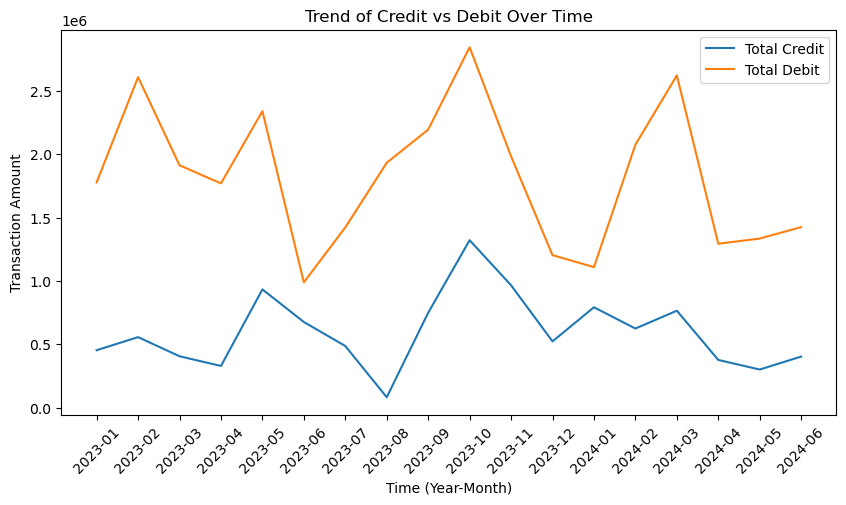

In [144]:
monthly_summary['YearMonth'] = (
    monthly_summary['Year'].astype(str) + '-' +
    monthly_summary['Month'].astype(str).str.zfill(2)
)

plt.figure(figsize=(10,5))

plt.plot(monthly_summary['YearMonth'],
         monthly_summary['Total_Credit'],
         label='Total Credit')

plt.plot(monthly_summary['YearMonth'],
         monthly_summary['Total_Debit'],
         label='Total Debit')

plt.xticks(rotation=45)
plt.xlabel('Time (Year-Month)')
plt.ylabel('Transaction Amount')
plt.title('Trend of Credit vs Debit Over Time')

plt.legend()
plt.show()

A time-series line plot was used to analyze the trend of total credit and debit transactions. 
It was observed that debit transactions consistently remained higher than credit transactions across all months, indicating a sustained outflow of funds.

The gap between credit and debit values varied across months, with notable peaks in debit transactions around October 2023 and early 2024. Despite occasional increases in credit, debit transactions continued to dominate, suggesting higher spending or withdrawal behavior.

The overall trend indicates fluctuating transaction patterns with no stable growth, reflecting volatility in customer financial behavior.

# 3- Identify top and bottom performing accounts based on net inflow.

In [145]:
# Create Credit & Debit columns
df['Credit'] = df['TransactionAmount'].where(df['TransactionType'] == 'Deposit', 0)

df['Debit'] = df['TransactionAmount'].where(
    df['TransactionType'].isin(['Withdrawal', 'Payment', 'Transfer']), 0
)

In [146]:
# Group by AccountID
account_summary = df.groupby('AccountID')[['Credit', 'Debit']].sum()
account_summary

,Credit,Debit
AccountID,,
ACC10117,56402.84,190484.45
ACC10996,60870.24,297946.78
ACC11062,0.00,328776.97
ACC11188,138883.98,247535.05
ACC11285,71079.93,213360.60
...,...,...
ACC97225,74213.78,31988.72
ACC97411,0.00,416659.90
ACC99117,92159.60,0.00


In [147]:
# Calculate Net Inflow
account_summary['Net_Inflow'] = (
    account_summary['Credit'] - account_summary['Debit']
)
account_summary['Net_Inflow']

AccountID
ACC10117   -134081.61
ACC10996   -237076.55
ACC11062   -328776.97
ACC11188   -108651.07
ACC11285   -142280.67
              ...    
ACC97225     42225.05
ACC97411   -416659.90
ACC99117     92159.60
ACC99409   -155509.75
ACC99549   -308910.22
Name: Net_Inflow, Length: 192, dtype: float64

In [148]:
# Identify Top Accounts
top_accounts = account_summary.sort_values(
    by='Net_Inflow', ascending=False
).head(5)
top_accounts

,Credit,Debit,Net_Inflow
AccountID,,,
ACC88286,284230.60,0.00,284230.60
ACC21719,281795.52,7066.33,274729.19
ACC51200,251699.76,50230.03,201469.73
ACC28295,262087.21,62636.52,199450.69
ACC83269,180850.73,0.00,180850.73


In [149]:
# Identify Bottom Accounts
bottom_accounts = account_summary.sort_values(
    by='Net_Inflow'
).head(5)
bottom_accounts

,Credit,Debit,Net_Inflow
AccountID,,,
ACC45101,35224.63,475972.23,-440747.60
ACC70460,0.00,432195.23,-432195.23
ACC97411,0.00,416659.90,-416659.90
ACC52650,0.00,387133.82,-387133.82
ACC77592,0.00,383553.32,-383553.32


Top accounts:
High positive Net_Inflow
:- Strong, stable customers

Bottom accounts:
Large negative Net_Inflow
:- High spending / risky

Net inflow was calculated for each account as the difference between total credit and total debit transactions. Accounts were then ranked based on their net inflow values.

The top-performing accounts exhibited high positive net inflow, indicating strong deposit behavior and financial stability.

In contrast, the bottom-performing accounts showed significant negative net inflow, suggesting higher withdrawal activity and potential financial risk.

So, Accounts with consistently negative net inflow may require monitoring, as they reflect higher outflow patterns that could indicate financial stress or over-reliance on withdrawals.

# 4- Identify and flag accounts as dormant or inactive if there is a gap of two months or more between consecutive transactions.

In [150]:
# Sort the data
df = df.sort_values(['AccountID', 'TransactionDate'])

In [151]:
# Get previous transaction date
df['PreviousDate'] = df.groupby('AccountID')['TransactionDate'].shift(1)

In [152]:
# Calculate gap between transactions
df['GapDays'] = (df['TransactionDate'] - df['PreviousDate']).dt.days
df['GapDays']

549      NaN
301    15.00
724    72.00
787    21.00
27     13.00
       ...  
398   133.00
336      NaN
303    15.00
139     7.00
581   312.00
Name: GapDays, Length: 800, dtype: float64

In [153]:
# Flag dormant cases
df['Dormant'] = df['GapDays'] > 60

In [154]:
account_dormant = df.groupby('AccountID')['Dormant'].any().reset_index()
account_dormant

,AccountID,Dormant
0,ACC10117,True
1,ACC10996,True
2,ACC11062,True
3,ACC11188,True
4,ACC11285,True
...,...,...
187,ACC97225,True
188,ACC97411,True
189,ACC99117,False
190,ACC99409,True


In [155]:
# flagged accounts only
account_dormant[account_dormant['Dormant'] == True]

,AccountID,Dormant
0,ACC10117,True
1,ACC10996,True
2,ACC11062,True
3,ACC11188,True
4,ACC11285,True
...,...,...
186,ACC96868,True
187,ACC97225,True
188,ACC97411,True
190,ACC99409,True


Total unique accounts = 192
Dormant accounts = 172

That means:

Most accounts had at least one inactive period

The high number of dormant accounts suggests irregular transaction behavior and potential gaps in customer engagement, which may require targeted reactivation strategies. 

### Task 3: Customer Profile Building 

# 1 -  Group accounts by activity levels: High, Medium, Low based on transaction frequency on your analysis and rubrics. Do not forget to mention the rubric in the headings.

In [156]:
# Calculate transaction frequency
account_freq = df.groupby('AccountID').size().reset_index(name='Transaction_Count')
account_freq

,AccountID,Transaction_Count
0,ACC10117,6
1,ACC10996,4
2,ACC11062,6
3,ACC11188,9
4,ACC11285,5
...,...,...
187,ACC97225,3
188,ACC97411,8
189,ACC99117,1
190,ACC99409,3


Rubric
-------
High Activity    → Transaction_Count ≥ 6  
Medium Activity  → Transaction_Count between 3 and 5  
Low Activity     → Transaction_Count ≤ 2  

In [157]:
def classify_activity(count):
    if count >= 6:
        return 'High'
    elif count >= 3:
        return 'Medium'
    else:
        return 'Low'

account_freq['Activity_Level'] = account_freq['Transaction_Count'].apply(classify_activity)

In [158]:
account_freq

,AccountID,Transaction_Count,Activity_Level
0,ACC10117,6,High
1,ACC10996,4,Medium
2,ACC11062,6,High
3,ACC11188,9,High
4,ACC11285,5,Medium
...,...,...,...
187,ACC97225,3,Medium
188,ACC97411,8,High
189,ACC99117,1,Low
190,ACC99409,3,Medium


In [159]:
account_freq['Activity_Level'].value_counts()

Activity_Level
Medium    105
High       45
Low        42
Name: count, dtype: int64

Based on the defined rubric, accounts were categorized into High, Medium, and Low activity levels.

It was observed that

1. Majority are Medium activity (105)

Most accounts have moderate transaction frequency

- Interpretation:

Users are somewhat engaged
But not very active

2. High activity accounts are fewer (45)

Only ~23% accounts are highly active

- Interpretation:

These are your most valuable users
Frequent usage → strong engagement

3. Low activity accounts are also significant (42) m

~22% accounts have very low transactions

- Interpretation:

These users are:
disengaged
occasional users
potential churn risk


# Despite a large number of medium activity accounts, the presence of significant dormant accounts and consistent net outflows suggests that transaction frequency alone does not guarantee sustained financial engagement.

# 2 -  Segment customers by average balance and transaction volume.

In [160]:
# Create customer-level summary
customer_summary = df.groupby('AccountID').agg({
    'AccountBalance': 'mean',
    'TransactionAmount': 'sum'
}).reset_index()
customer_summary

,AccountID,AccountBalance,TransactionAmount
0,ACC10117,81106.21,246887.29
1,ACC10996,101733.90,358817.02
2,ACC11062,57108.76,328776.97
3,ACC11188,80235.15,386419.02
4,ACC11285,71205.65,284440.53
...,...,...,...
187,ACC97225,53496.78,106202.50
188,ACC97411,89407.83,416659.90
189,ACC99117,106391.25,92159.60
190,ACC99409,55933.33,155509.75


In [161]:
# Rename columns
customer_summary.rename(columns={
    'AccountBalance': 'Avg_Balance',
    'TransactionAmount': 'Total_Transaction'
}, inplace=True)

In [162]:
customer_summary

,AccountID,Avg_Balance,Total_Transaction
0,ACC10117,81106.21,246887.29
1,ACC10996,101733.90,358817.02
2,ACC11062,57108.76,328776.97
3,ACC11188,80235.15,386419.02
4,ACC11285,71205.65,284440.53
...,...,...,...
187,ACC97225,53496.78,106202.50
188,ACC97411,89407.83,416659.90
189,ACC99117,106391.25,92159.60
190,ACC99409,55933.33,155509.75


In [163]:
# Understand data distribution
customer_summary.describe()

,Avg_Balance,Total_Transaction
count,192.00,192.00
mean,74990.71,227091.11
std,21351.53,123839.16
min,23319.34,10392.70
25%,63455.06,137910.28
50%,72577.43,207930.11
75%,85165.73,295923.08
max,171767.66,765315.96


High Value Customer:
→ Avg_Balance ≥ 85,000 AND Total_Transaction ≥ 295,000

Medium Value Customer:
→ Avg_Balance between 63,000 – 85,000 AND Total_Transaction between 137,000 – 295,000

Low Value Customer:
Avg_Balance < 63,000  OR Total_Transaction < 137,000

In [164]:
# Create segmentation function
def segment_customer(row):
    if row['Avg_Balance'] >= 85000 and row['Total_Transaction'] >= 295000:
        return 'High Value'
    elif row['Avg_Balance'] >= 63000 and row['Total_Transaction'] >= 137000:
        return 'Medium Value'
    else:
        return 'Low Value'


# Apply segmentation
customer_summary['Customer_Segment'] = customer_summary.apply(segment_customer, axis=1)

In [165]:
customer_summary

,AccountID,Avg_Balance,Total_Transaction,Customer_Segment
0,ACC10117,81106.21,246887.29,Medium Value
1,ACC10996,101733.90,358817.02,High Value
2,ACC11062,57108.76,328776.97,Low Value
3,ACC11188,80235.15,386419.02,Medium Value
4,ACC11285,71205.65,284440.53,Medium Value
...,...,...,...,...
187,ACC97225,53496.78,106202.50,Low Value
188,ACC97411,89407.83,416659.90,High Value
189,ACC99117,106391.25,92159.60,Low Value
190,ACC99409,55933.33,155509.75,Low Value


In [166]:
# Distribution of segments
customer_summary['Customer_Segment'].value_counts()

Customer_Segment
Medium Value    98
Low Value       85
High Value       9
Name: count, dtype: int64

1. Medium Value (Majority) - 98 (~51%)

About half of your customers fall here.

- Moderate balance
- Moderate transaction activity
- These are your stable but not highly valuable users

2. Low Value (Large chunk) - 85 (~44%)

Nearly as many as Medium

- Low balance OR low transaction volume
- Indicates:
      - low engagement
      - low financial contribution

:- This is a risk group

3. High Value (Very small group)

Only 9 accounts (~5%)

- High balance
- High transaction volume

:- These are : Your most important customers

# This distribution indicates that while a significant number of customers maintain moderate engagement, very few contribute high financial value, suggesting an opportunity to enhance engagement and retention strategies.

# 3- Create profiles for:
○ High-net inflow accounts
○ High-frequency low-balance accounts
○ Accounts with negative or near-zero balances

In [169]:
profile_df = account_summary.copy()

profile_df = profile_df.merge(account_freq, on='AccountID')
profile_df = profile_df.merge(customer_summary[['AccountID', 'Avg_Balance']], on='AccountID')

In [102]:
profile_df

,AccountID,Credit,Debit,Net_Inflow,Transaction_Count,Avg_Balance
0,ACC10117,56402.84,190484.45,-134081.61,6,81106.21
1,ACC10996,60870.24,297946.78,-237076.55,4,101733.90
2,ACC11062,0.00,328776.97,-328776.97,6,57108.76
3,ACC11188,138883.98,247535.05,-108651.07,9,80235.15
4,ACC11285,71079.93,213360.60,-142280.67,5,71205.65
...,...,...,...,...,...,...
187,ACC97225,74213.78,31988.72,42225.05,3,53496.78
188,ACC97411,0.00,416659.90,-416659.90,8,89407.83
189,ACC99117,92159.60,0.00,92159.60,1,106391.25
190,ACC99409,0.00,155509.75,-155509.75,3,55933.33


In [178]:
profile_df.describe()

,Credit,Debit,Net_Inflow,Transaction_Count,Avg_Balance
count,192.00,192.00,192.00,192.00,192.00
mean,55963.99,171127.12,-115163.13,4.17,74990.71
std,65768.78,110409.46,133024.15,2.02,21351.53
min,0.00,-6489.54,-440747.60,1.00,23319.34
25%,0.00,84319.54,-208043.13,3.00,63455.06
50%,38418.64,160609.82,-122366.85,4.00,72577.43
75%,86176.74,235081.11,-33986.34,5.00,85165.73
max,292631.40,483487.42,284230.60,13.00,171767.66


High Net Inflow  
Net_Inflow ≥ 0

High Frequency
Transaction_Count ≥ 6

Low Balance
Avg_Balance < 63,000 

Near-zero balance
Avg_Balance < 30,000  

# High Net Inflow Accounts
threshold = profile_df['Net_Inflow'].quantile(0.75)
high_inflow = profile_df[profile_df['Net_Inflow'] >= threshold]

In [179]:
# High Net Inflow Accounts
high_inflow = profile_df[profile_df['Net_Inflow'] > 0]

In [180]:
# High Frequency + Low Balance
high_freq_low_bal = profile_df[
    (profile_df['Transaction_Count'] >= 6) &
    (profile_df['Avg_Balance'] < 63000)
]

In [181]:
# Negative or Near-Zero Balance
neg_low_balance = profile_df[
    profile_df['Avg_Balance'] < 30000
]

In [182]:
len(high_inflow)

39

In [183]:
len(high_freq_low_bal)

12

In [184]:
len(neg_low_balance)

3

### Task 4: Financial Risk Identification 

# 1. Track accounts with frequent large withdrawals or overdrafts.

In [185]:
# money going out
withdrawals = df[df['TransactionType'].isin(['Withdrawal', 'Payment', 'Transfer'])]

In [186]:
withdrawals.describe()

,TransactionID,TransactionDate,TransactionAmount,AccountBalance,RiskScore,CreditRating,TenureMonths,Year,Month,Credit,Debit,PreviousDate,GapDays
count,618.00,618,618.00,618.00,618.00,618.00,618.00,618.00,618.00,618.00,618.00,468,468.00
mean,98.65,2023-09-18 23:15:43.689320192,53165.71,72317.31,0.46,578.55,123.77,2023.30,5.55,0.00,53165.71,2023-07-31 23:41:32.307692288,92.31
min,1.00,2023-01-06 00:00:00,-27916.91,-35891.00,-0.29,306.00,6.00,2023.00,1.00,0.00,-27916.91,2023-01-06 00:00:00,0.00
25%,49.00,2023-05-08 00:00:00,33175.13,50254.84,0.31,451.25,67.00,2023.00,3.00,0.00,33175.13,2023-04-10 12:00:00,24.00
50%,96.00,2023-09-26 00:00:00,53874.52,72906.91,0.46,572.00,122.50,2023.00,5.00,0.00,53874.52,2023-07-30 00:00:00,66.00
75%,150.00,2024-02-05 00:00:00,72196.24,93331.18,0.63,711.75,182.75,2024.00,9.00,0.00,72196.24,2023-11-06 06:00:00,136.00
max,199.00,2024-06-22 00:00:00,165004.54,171767.66,1.16,849.00,239.00,2024.00,12.00,0.00,165004.54,2024-06-07 00:00:00,435.00
std,58.63,NaN,29838.98,33857.87,0.24,153.60,67.62,0.46,3.36,0.00,29838.98,NaN,87.14


In [188]:
# large withdrawals
threshold = withdrawals['TransactionAmount'].quantile(0.75)

In [189]:
# Filter large withdrawals
large_withdrawals = withdrawals[
    withdrawals['TransactionAmount'] >= threshold
]

In [190]:
# Count how often each account does this
lw_count = (
    large_withdrawals
    .groupby('AccountID')
    .size()
    .reset_index(name='Large_Withdrawal_Count')
)
lw_count

,AccountID,Large_Withdrawal_Count
0,ACC10996,3
1,ACC11062,1
2,ACC11188,1
3,ACC11285,2
4,ACC11837,1
...,...,...
97,ACC96277,2
98,ACC96868,2
99,ACC97411,2
100,ACC99409,2


In [192]:
# frequentlt large withdrawls
frequent_large_withdrawals = lw_count[
    lw_count['Large_Withdrawal_Count'] >= 3
]

frequent_large_withdrawals

,AccountID,Large_Withdrawal_Count
0,ACC10996,3
19,ACC24070,3
26,ACC29007,3
33,ACC35419,3
43,ACC45101,3
61,ACC62446,3
70,ACC71938,3
75,ACC77592,3
76,ACC77638,4
81,ACC81631,3


In [ ]:
# Overdraft Accounts

In [193]:
# Find negative balances
overdraft_accounts = df[df['AccountBalance'] < 0]['AccountID'].unique()

In [194]:
# Create final risky list
risky_accounts = set(frequent_large_withdrawals['AccountID'])
risky_accounts.update(overdraft_accounts)

risky_accounts = list(risky_accounts)
len(risky_accounts)

26

In [196]:
risky_df = profile_df[profile_df['AccountID'].isin(risky_accounts)]
risky_df

,AccountID,Credit,Debit,Net_Inflow,Transaction_Count,Activity_Level,Avg_Balance
1,ACC10996,60870.24,297946.78,-237076.55,4,Medium,101733.90
2,ACC11062,0.00,328776.97,-328776.97,6,High,57108.76
11,ACC15671,0.00,134497.96,-134497.96,3,Medium,27077.57
26,ACC22036,22354.42,199281.55,-176927.13,6,High,74872.56
31,ACC24070,0.00,338136.69,-338136.69,5,Medium,53811.39
46,ACC29007,13386.81,242910.53,-229523.72,4,Medium,67857.44
53,ACC30787,156080.01,250625.27,-94545.26,6,High,76017.62
64,ACC34821,35825.33,186421.99,-150596.67,4,Medium,23319.34
66,ACC35419,32955.23,398856.44,-365901.20,6,High,53390.33
73,ACC39529,48251.35,96918.42,-48667.06,3,Medium,62774.93


# A small but significant portion of accounts (26 out of 192) exhibit risky financial behavior, characterized by frequent high-value withdrawals or negative balances. These accounts may require monitoring and risk mitigation strategies.

# 2 Calculate balance volatility using standard deviation or coefficient of variation.

In [198]:
# Calculate standard deviation
balance_std = df.groupby('AccountID')['AccountBalance'].std()
balance_std

AccountID
ACC10117   30732.94
ACC10996   12477.43
ACC11062   40017.80
ACC11188   25420.45
ACC11285   35772.56
             ...   
ACC97225   51171.43
ACC97411   30357.59
ACC99117        NaN
ACC99409   46489.35
ACC99549   20655.29
Name: AccountBalance, Length: 192, dtype: float64

In [199]:
balance_std = balance_std.reset_index(name='Balance_STD')

In [200]:
balance_std

,AccountID,Balance_STD
0,ACC10117,30732.94
1,ACC10996,12477.43
2,ACC11062,40017.80
3,ACC11188,25420.45
4,ACC11285,35772.56
...,...,...
187,ACC97225,51171.43
188,ACC97411,30357.59
189,ACC99117,NaN
190,ACC99409,46489.35


In [201]:
balance_std['Balance_STD'].describe()

count     184.00
mean    30746.74
std     16582.28
min       791.57
25%     18377.11
50%     29221.08
75%     40074.99
max     91165.11
Name: Balance_STD, dtype: float64

In [202]:
# high volatility accounts
threshold = 40074  # from 75% value
high_volatility_accounts = balance_std[
    balance_std['Balance_STD'] >= threshold
]

In [203]:
high_volatility_accounts

,AccountID,Balance_STD
21,ACC20297,70164.03
24,ACC21719,49213.50
26,ACC22036,57748.82
44,ACC28305,59418.13
45,ACC28612,44658.87
50,ACC29477,57288.20
51,ACC29646,52487.98
52,ACC30146,52382.75
53,ACC30787,43086.30
64,ACC34821,48974.25


Balance Volatility Analysis
-----------------------------
The standard deviation of account balances was calculated to measure volatility.

The average volatility across accounts was approximately 30,746, with values ranging from 791 to 91,165.

The 75th percentile value (40,074) was used as a threshold to identify high volatility accounts.

Accounts exceeding this threshold were classified as highly volatile, indicating unstable financial behavior.

# 3. Use IQR or z-score methods to detect anomalies.

In [205]:
# Get Q1 and Q3
Q1 = df['TransactionAmount'].quantile(0.25)
Q3 = df['TransactionAmount'].quantile(0.75)
IQR = Q3 - Q1

In [206]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [207]:
lower_bound

np.float64(-23726.616456250013)

In [208]:
upper_bound

np.float64(131812.84649375)

In [209]:
# Detect anomalies
anomalies = df[
    (df['TransactionAmount'] < lower_bound) |
    (df['TransactionAmount'] > upper_bound)
]

In [211]:
anomalies

,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,...,RiskScore,CreditRating,TenureMonths,Year,Month,Credit,Debit,PreviousDate,GapDays,Dormant
264,133,CUST4780,ACC18057,Savings,Payment,Personal Loan,Firm D,Central,Manager 2,2023-11-25,...,0.59,548,220,2023,11,0.00,144421.84,2023-10-21,35.00,False
168,141,CUST2443,ACC21719,Current,Deposit,Home Loan,Firm E,North,Manager 2,2023-06-18,...,0.33,595,15,2023,6,155241.43,0.00,2023-04-14,65.00,True
306,190,CUST6565,ACC41829,Loan,Payment,Home Loan,Firm B,Central,Manager 3,2024-03-12,...,0.32,808,27,2024,3,0.00,144271.27,2024-02-04,37.00,False
755,30,CUST1888,ACC45101,Credit,Payment,Savings Account,Firm A,Central,Manager 1,2023-04-19,...,0.37,619,175,2023,4,0.00,165004.54,2023-02-10,68.00,True
377,189,CUST1042,ACC83848,Loan,Payment,Personal Loan,Firm B,West,Manager 1,2024-02-09,...,0.46,753,73,2024,2,0.00,137999.19,2024-01-17,23.00,False
481,20,CUST7793,ACC88449,Current,Transfer,Credit Card,Firm D,North,Manager 4,2023-06-19,...,0.51,379,222,2023,6,0.00,-27916.91,2023-05-26,24.00,False
640,67,CUST1962,ACC94203,Savings,Deposit,Home Loan,Firm C,South,Manager 2,2024-06-07,...,0.45,608,129,2024,6,-27308.24,0.00,2023-09-06,275.00,True


In [212]:
len(anomalies)

7

# Anomalous transactions highlight extreme financial behavior, which may require further investigation for potential fraud or irregular activity.

In [214]:
# Start with empty set
suspicious_accounts = set()

In [215]:
# Add accounts with large withdrawals
suspicious_accounts.update(frequent_large_withdrawals['AccountID'])

In [216]:
# Add overdraft accounts
suspicious_accounts.update(overdraft_accounts)

In [218]:
# Add high volatility accounts
suspicious_accounts.update(high_volatility_accounts['AccountID'])

In [219]:
# Add anomaly accounts
suspicious_accounts.update(anomalies['AccountID'])

In [220]:
suspicious_accounts = list(suspicious_accounts)
len(suspicious_accounts)

62

In [221]:
suspicious_accounts

['ACC96868',
 'ACC80131',
 'ACC39529',
 'ACC78589',
 'ACC95164',
 'ACC76549',
 'ACC46953',
 'ACC87602',
 'ACC64393',
 'ACC34821',
 'ACC71938',
 'ACC94907',
 'ACC45521',
 'ACC21719',
 'ACC66190',
 'ACC83848',
 'ACC39500',
 'ACC49774',
 'ACC71426',
 'ACC76699',
 'ACC81631',
 'ACC66086',
 'ACC15671',
 'ACC97225',
 'ACC83005',
 'ACC29646',
 'ACC28612',
 'ACC45951',
 'ACC45101',
 'ACC35419',
 'ACC41829',
 'ACC39161',
 'ACC29477',
 'ACC74631',
 'ACC24070',
 'ACC11062',
 'ACC49422',
 'ACC29007',
 'ACC64022',
 'ACC22036',
 'ACC10996',
 'ACC94203',
 'ACC99409',
 'ACC38559',
 'ACC94242',
 'ACC20297',
 'ACC92360',
 'ACC88516',
 'ACC67713',
 'ACC30146',
 'ACC75675',
 'ACC77592',
 'ACC88252',
 'ACC77638',
 'ACC28305',
 'ACC49140',
 'ACC62446',
 'ACC30787',
 'ACC18057',
 'ACC47099',
 'ACC88449',
 'ACC39544']

In [222]:
suspicious_df = profile_df[
    profile_df['AccountID'].isin(suspicious_accounts)
]

suspicious_df.head()

,AccountID,Credit,Debit,Net_Inflow,Transaction_Count,Activity_Level,Avg_Balance
1,ACC10996,60870.24,297946.78,-237076.55,4,Medium,101733.90
2,ACC11062,0.00,328776.97,-328776.97,6,High,57108.76
11,ACC15671,0.00,134497.96,-134497.96,3,Medium,27077.57
16,ACC18057,102991.47,186393.64,-83402.16,3,Medium,102741.71
21,ACC20297,0.00,134018.22,-134018.22,2,Low,80846.69


### Task 5: Visualisation

# Conduct extensive exploratory data analysis with attractive visualizations for your findings

# Visualization 1: Credits vs Debits over time

In [ ]:
# Prepare data

df['Month'] = df['TransactionDate'].dt.to_period('M')

monthly_credit = df[df['TransactionType'] == 'Credit'].groupby('Month')['TransactionAmount'].sum()
monthly_debit = df[df['TransactionType'] != 'Credit'].groupby('Month')['TransactionAmount'].sum()

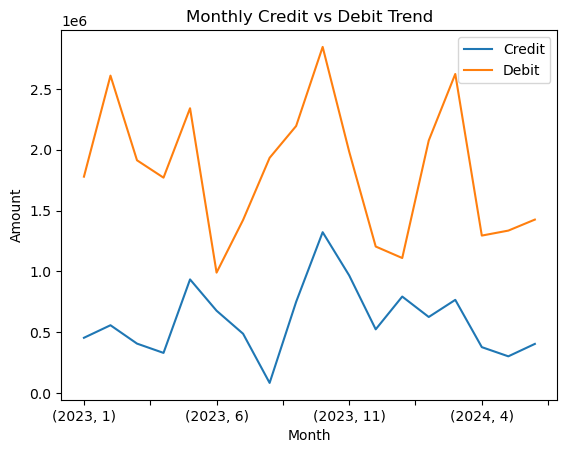

In [223]:
# Plot

plt.figure()
monthly_credit.plot(label='Credit')
monthly_debit.plot(label='Debit')

plt.title('Monthly Credit vs Debit Trend')
plt.xlabel('Month')
plt.ylabel('Amount')
plt.legend()
plt.show()

The transaction trend shows that debit transactions consistently exceed credit transactions, indicating higher outflow than inflow, which may lead to negative net balances over time.

# Visualization 2: Distribution of Transaction Amounts

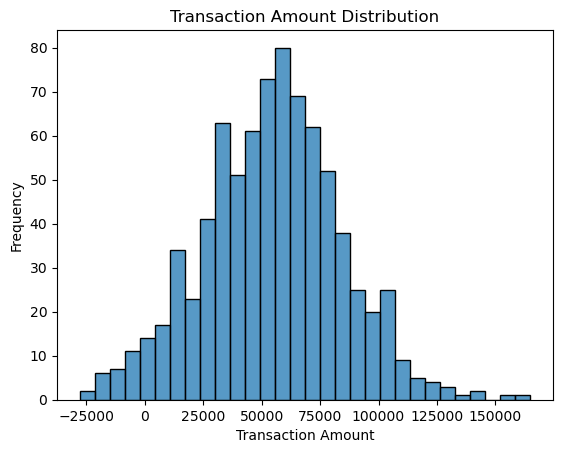

In [224]:
plt.figure()
sns.histplot(df['TransactionAmount'], bins=30)

plt.title('Transaction Amount Distribution')
plt.xlabel('Transaction Amount')
plt.ylabel('Frequency')
plt.show()

Transaction amounts are concentrated in the mid-range, with a few extreme values indicating potential outliers or high-value transactions

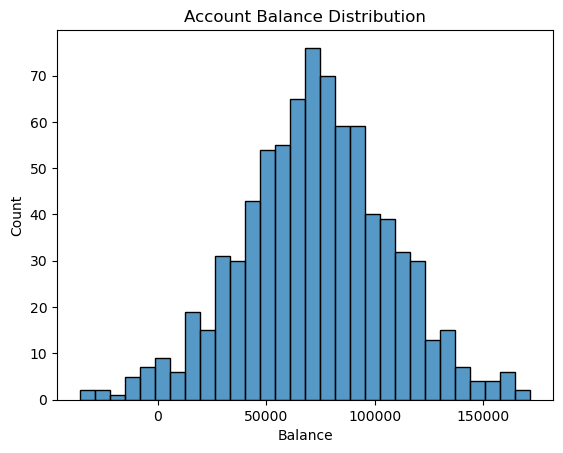

In [225]:
# Visualization 3: Account Balance Distribution
plt.figure()
sns.histplot(df['AccountBalance'], bins=30)

plt.title('Account Balance Distribution')
plt.xlabel('Balance')
plt.show()

Account balances are normally distributed around mid-range values, suggesting that most customers maintain moderate financial stability

In [ ]:
# Visualization 4: Top & Bottom Accounts (Net Inflow)

In [226]:
top_accounts = account_summary.sort_values(by='Net_Inflow', ascending=False).head(10)
bottom_accounts = account_summary.sort_values(by='Net_Inflow').head(10)

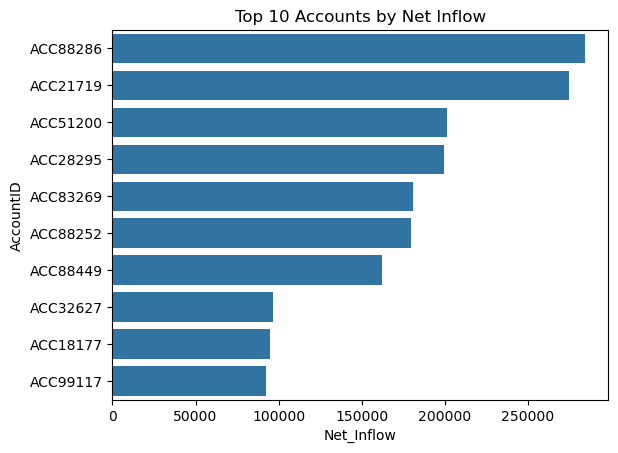

In [227]:
plt.figure()
sns.barplot(x='Net_Inflow', y='AccountID', data=top_accounts)

plt.title('Top 10 Accounts by Net Inflow')
plt.show()

A small number of accounts contribute significantly to net inflow, indicating concentration of financial value among top-performing customers.

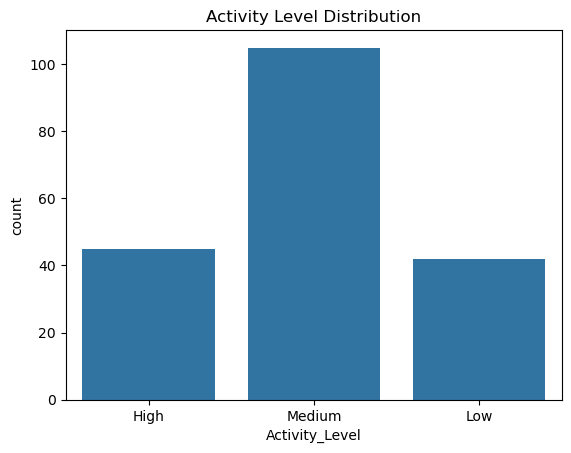

In [228]:
# Visualization 5: Activity Level Distribution

plt.figure()
sns.countplot(x='Activity_Level', data=account_freq)

plt.title('Activity Level Distribution')
plt.show()

The majority of accounts fall under the medium activity category, indicating balanced transaction frequency across most customers.

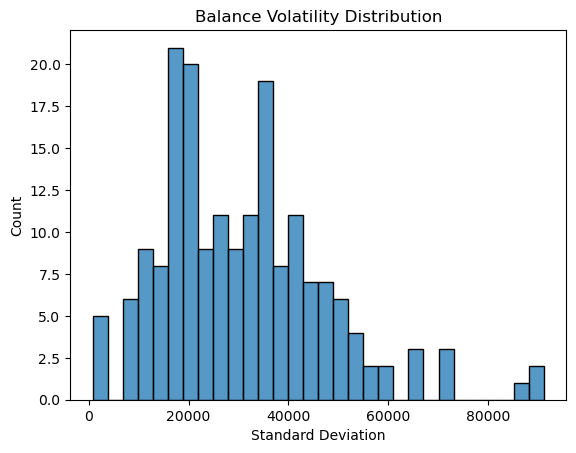

In [229]:
# Visualization 6: Balance Volatility

plt.figure()
sns.histplot(balance_std['Balance_STD'], bins=30)

plt.title('Balance Volatility Distribution')
plt.xlabel('Standard Deviation')
plt.show()

Most accounts are moderately stable, some are highly unstable.

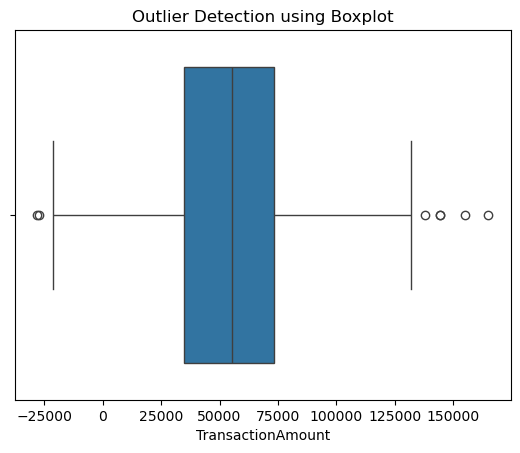

In [230]:
# Visualization 7: Anomaly Detection

plt.figure()
sns.boxplot(x=df['TransactionAmount'])

plt.title('Outlier Detection using Boxplot')
plt.show()

The presence of outliers on both ends indicates unusual transaction amounts, which may represent irregular or suspicious financial activity.

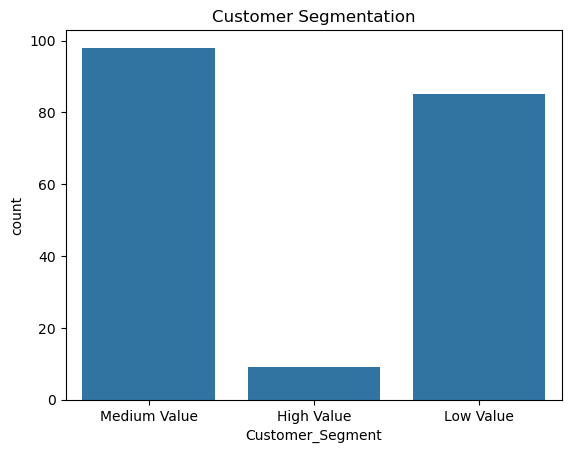

In [231]:
# Visualization 8: Customer Segmentation
plt.figure()
sns.countplot(x='Customer_Segment', data=customer_summary)

plt.title('Customer Segmentation')
plt.show()

The majority of customers fall into the medium-value segment, while only a small proportion contributes high value, indicating limited high-value customer concentration.

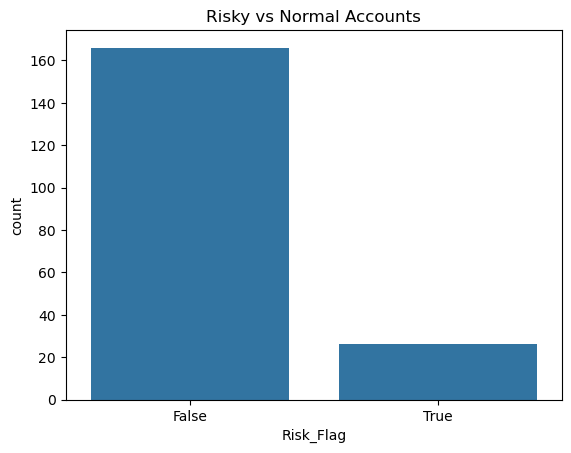

In [232]:
# Visualization 9: Risky vs Normal Accounts
profile_df['Risk_Flag'] = profile_df['AccountID'].isin(risky_accounts)

plt.figure()
sns.countplot(x='Risk_Flag', data=profile_df)

plt.title('Risky vs Normal Accounts')
plt.show()

A small proportion of accounts are identified as risky, suggesting that while most customers exhibit stable behavior, a subset requires monitoring.

# Final overall insight

The analysis reveals that while most customers maintain moderate balances and activity levels, a small segment exhibits high volatility, anomalous transactions, and risky behavior. Additionally, debit transactions consistently exceed credits, indicating a general trend of higher outflow. These patterns highlight the presence of financial risk among specific accounts and the concentration of value among a limited number of customers.

### Task 6: Hypothesis Testing

# 1. Test whether high-volume transaction accounts have statistically higher average balances than low-volume accounts.

In [233]:
# Define groups (High vs Low)
high_volume = account_freq[account_freq['Activity_Level'] == 'High']
low_volume = account_freq[account_freq['Activity_Level'] == 'Low']

In [234]:
# Step 2: Add balance information
high_volume = high_volume.merge(customer_summary[['AccountID', 'Avg_Balance']], on='AccountID')
low_volume = low_volume.merge(customer_summary[['AccountID', 'Avg_Balance']], on='AccountID')

In [236]:
high_volume

,AccountID,Transaction_Count,Activity_Level,Avg_Balance
0,ACC10117,6,High,81106.21
1,ACC11062,6,High,57108.76
2,ACC11188,9,High,80235.15
3,ACC11837,6,High,69822.57
4,ACC16241,9,High,84908.40
5,ACC22036,6,High,74872.56
6,ACC25811,7,High,79173.97
7,ACC26956,6,High,80144.57
8,ACC28154,9,High,69366.70
9,ACC29231,6,High,102089.72


In [237]:
low_volume

,AccountID,Transaction_Count,Activity_Level,Avg_Balance
0,ACC12334,2,Low,71687.82
1,ACC15228,2,Low,130695.13
2,ACC15359,2,Low,78764.24
3,ACC20297,2,Low,80846.69
4,ACC21429,2,Low,66728.30
5,ACC23985,2,Low,90980.53
6,ACC24508,2,Low,97629.13
7,ACC25132,1,Low,152303.90
8,ACC26973,2,Low,50183.24
9,ACC28292,1,Low,74043.86


In [238]:
# Step 3: Extract balance values
high_bal = high_volume['Avg_Balance']
low_bal = low_volume['Avg_Balance']

In [239]:
high_bal

0     81106.21
1     57108.76
2     80235.15
3     69822.57
4     84908.40
5     74872.56
6     79173.97
7     80144.57
8     69366.70
9    102089.72
10    72232.23
11    76017.62
12    83689.89
13    55556.76
14    53390.33
15    94256.39
16    61628.66
17    59242.76
18    65679.95
19    49875.37
20    72398.41
21    75266.25
22    79387.95
23    78290.97
24    71688.03
25    70396.22
26    72599.17
27    47266.09
28    82775.15
29    65782.38
30    91249.05
31    73479.80
32    81387.86
33    84818.40
34    56524.02
35    63568.36
36    54284.43
37    60382.95
38    86836.52
39    65004.13
40    56191.52
41    64820.01
42    81714.81
43    53257.61
44    89407.83
Name: Avg_Balance, dtype: float64

In [ ]:
# Step 4: Define hypothesis 

In [ ]:
'' Null Hypothesis (H₀)

No difference in balances

H₀: μ_high = μ_low

In [ ]:
'' Alternative Hypothesis (H₁)

High-volume accounts have higher balances

H₁: μ_high > μ_low

In [240]:
# Step 5: Perform t-test

from scipy.stats import ttest_ind

t_stat, p_value = ttest_ind(high_bal, low_bal, alternative='greater')

In [241]:
p_value

np.float64(0.9991025248472124)

In [243]:
p_value > 0.05 
print(" Fail to reject the null hypothesis H₀ ")

 Fail to reject the null hypothesis H₀ 


There is NO statistical evidence that high-volume accounts have higher balances.

# 2 Conduct hypothesis testing based on segmentation.

In [244]:
# Create groups
high_value = customer_summary[customer_summary['Customer_Segment'] == 'High Value']
low_value = customer_summary[customer_summary['Customer_Segment'] == 'Low Value']

In [245]:
# Extract balance values
high_bal = high_value['Avg_Balance']
low_bal = low_value['Avg_Balance']

In [ ]:
# Step 3: Define hypothesis

In [ ]:
'' Null Hypothesis (H₀)

No difference between groups

H₀: μ_high = μ_low



Alternative Hypothesis (H₁)

High-value customers have higher balance

H₁: μ_high > μ_low

In [246]:
# Step 4: Perform t-test

t_stat, p_value = ttest_ind(high_bal, low_bal, alternative='greater')

In [247]:
# Step 5: Check p-value
p_value

np.float64(0.0009848430220941564)

In [249]:
p_value < 0.05
print("Segmentation is meaningful , groups are actually different")

Segmentation is meaningful , groups are actually different


# There IS a statistically significant difference between the two groups.

# Final Combined Insight
Customer value segmentation is statistically meaningful, whereas transaction frequency alone is not a reliable indicator of financial strength.